In [2]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import sys
import os
from pathlib import Path

REPO_ROOT = Path('/Users/dhillo/Garage/codeComplete/full measure/warfarin/')

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))



In [3]:
from src.bandits.epsilon_greedy_bandit import *
from src.bandits.linUCB import *
from src.bandits.thompson_sampling import *

In [5]:
# Load the dataset
df = pd.read_csv('output/warfarin_one_hot_encoded_full_power.csv')
# Get the number of arms from the number of unique labels
n_arms = df['Therapeutic Dose of Warfarin'].nunique()
df.shape, n_arms


((5528, 168), 3)

In [9]:
for c in df.columns:
    print(c)

Height (cm)
Weight (kg)
Therapeutic Dose of Warfarin
Acetaminophen or Paracetamol (Tylenol)_0.0
Acetaminophen or Paracetamol (Tylenol)_1.0
Age_1
Age_2
Age_3
Age_4
Age_5
Age_6
Age_7
Age_8
Age_9
Amiodarone (Cordarone)_0.0
Amiodarone (Cordarone)_1.0
Anti-fungal Azoles_0.0
Anti-fungal Azoles_1.0
Aspirin_0.0
Aspirin_1.0
Atorvastatin (Lipitor)_0.0
Atorvastatin (Lipitor)_1.0
CYP2C9 consensus_*1/*1
CYP2C9 consensus_*1/*11
CYP2C9 consensus_*1/*13
CYP2C9 consensus_*1/*14
CYP2C9 consensus_*1/*2
CYP2C9 consensus_*1/*3
CYP2C9 consensus_*1/*5
CYP2C9 consensus_*1/*6
CYP2C9 consensus_*2/*2
CYP2C9 consensus_*2/*3
CYP2C9 consensus_*3/*3
CYP2C9 consensus_Unknown
Carbamazepine (Tegretol)_False
Carbamazepine (Tegretol)_True
Cerivastatin (Baycol)_0.0
Combined QC CYP2C9_*1/*1
Combined QC CYP2C9_*1/*2
Combined QC CYP2C9_*1/*3
Combined QC CYP2C9_*2/*2
Combined QC CYP2C9_*2/*3
Combined QC CYP2C9_*3/*3
Congestive Heart Failure and/or Cardiomyopathy_0.0
Congestive Heart Failure and/or Cardiomyopathy_1.0
Current S

In [7]:
df.head

<bound method NDFrame.head of       Height (cm)  Weight (kg)  Therapeutic Dose of Warfarin  \
0          193.04        115.7                             1   
1          176.53        144.2                             1   
2          162.56         77.1                             2   
3          182.24         90.7                             1   
4          167.64         72.6                             1   
...           ...          ...                           ...   
5523       185.42        113.6                             2   
5524       160.02         55.9                             1   
5525       187.96         97.7                             2   
5526       177.80         87.3                             2   
5527       190.50         79.6                             1   

      Acetaminophen or Paracetamol (Tylenol)_0.0  \
0                                          False   
1                                          False   
2                                          Fa

# epsilon greedy bandit

In [5]:
# Set up the simulation
n_iterations = 20
cumulative_regrets = []
average_accuracies = []


for i in range(n_iterations):
    # Shuffle the dataset
    df_shuffled = shuffle(df, random_state=i)
    
    # Split the data into features and labels
    X = df_shuffled.drop('Therapeutic Dose of Warfarin', axis=1).values
    y = df_shuffled['Therapeutic Dose of Warfarin'].values
    
    # Initialize the bandit
    bandit = EpsilonGreedyBandit(n_arms)
    
    # Track performance
    correct_predictions = 0
    cumulative_regret = 0
    
    # Simulate the bandit selecting arms and receiving reward
    for j in range(len(df_shuffled)):
        # The bandit makes a prediction (selects an arm)
        chosen_arm = bandit.select_arm()
        
        # Get the actual label
        actual_label = y[j]
        
        # Check if the bandit's prediction was correct
        if chosen_arm == actual_label:
            reward = 1
            correct_predictions += 1
        else:
            reward = 0
            
        # Update the bandit with the reward for the chosen arm
        bandit.update(chosen_arm, reward)
        
        # Calculate regret (difference between the optimal and chosen action)
        optimal_reward = 1  # assuming the optimal action would always be correct
        regret = optimal_reward - reward
        cumulative_regret += regret
    
    # Store the cumulative regret for this iteration
    cumulative_regrets.append(cumulative_regret)
    
    # Calculate accuracy for this iteration
    accuracy = correct_predictions / len(df_shuffled)
    average_accuracies.append(accuracy)
    
    print(f"Iteration {i+1}: Accuracy = {accuracy}, Cumulative Regret = {cumulative_regret}")

# Calculate the average accuracy over all iterations
final_average_accuracy = np.mean(average_accuracies)
print(f"Average Accuracy over {n_iterations} iterations: {final_average_accuracy}")



Iteration 1: Accuracy = 0.5806801736613604, Cumulative Regret = 2318
Iteration 2: Accuracy = 0.5774240231548481, Cumulative Regret = 2336
Iteration 3: Accuracy = 0.5839363241678727, Cumulative Regret = 2300
Iteration 4: Accuracy = 0.5877351664254703, Cumulative Regret = 2279
Iteration 5: Accuracy = 0.5734442836468886, Cumulative Regret = 2358
Iteration 6: Accuracy = 0.5830318379160637, Cumulative Regret = 2305
Iteration 7: Accuracy = 0.5779667149059334, Cumulative Regret = 2333
Iteration 8: Accuracy = 0.5794138929088278, Cumulative Regret = 2325
Iteration 9: Accuracy = 0.5786903039073806, Cumulative Regret = 2329
Iteration 10: Accuracy = 0.5743487698986975, Cumulative Regret = 2353
Iteration 11: Accuracy = 0.5738060781476122, Cumulative Regret = 2356
Iteration 12: Accuracy = 0.5833936324167872, Cumulative Regret = 2303
Iteration 13: Accuracy = 0.5828509406657019, Cumulative Regret = 2306
Iteration 14: Accuracy = 0.578328509406657, Cumulative Regret = 2331
Iteration 15: Accuracy = 0.583

# lin UCB

In [3]:

# Define parameters
alpha = 1.0  # Exploration parameter
n_iterations = 20
cumulative_regrets = []
average_accuracies = []

# Get the number of arms and features
n_arms = df['Therapeutic Dose of Warfarin'].nunique()
n_features = df.shape[1] - 1  # Number of features is total columns minus the label column

for i in range(n_iterations):
    df_shuffled = shuffle(df, random_state=i)
    X = df_shuffled.drop('Therapeutic Dose of Warfarin', axis=1).values
    y = df_shuffled['Therapeutic Dose of Warfarin'].values
    
    # Initialize the LinUCB model
    linucb = LinUCB(alpha, n_arms, n_features)
    
    correct_predictions = 0
    cumulative_regret = 0

    for j in tqdm(range(len(df_shuffled)), desc=f'Iteration {i+1}'):
        x = X[j]
        chosen_arm = linucb.select_arm(x)
        actual_label = y[j]
        
        reward = 1 if chosen_arm == actual_label else 0
        correct_predictions += reward
        
        linucb.update(chosen_arm, x, reward)
        
        optimal_reward = 1  # assuming the optimal action would always be correct
        regret = optimal_reward - reward
        cumulative_regret += regret
    
    cumulative_regrets.append(cumulative_regret)
    
    accuracy = correct_predictions / len(df_shuffled)
    average_accuracies.append(accuracy)
    
    print(f"Iteration {i+1}: Accuracy = {accuracy}, Cumulative Regret = {cumulative_regret}")

final_average_accuracy = np.mean(average_accuracies)
print(f"Average Accuracy over {n_iterations} iterations: {final_average_accuracy}")


Iteration 1: 100%|██████████| 5528/5528 [00:52<00:00, 105.81it/s]


Iteration 1: Accuracy = 0.6338639652677279, Cumulative Regret = 2024


Iteration 2: 100%|██████████| 5528/5528 [00:51<00:00, 107.52it/s]


Iteration 2: Accuracy = 0.6293415340086831, Cumulative Regret = 2049


Iteration 3: 100%|██████████| 5528/5528 [00:53<00:00, 103.06it/s]


...

Iteration 18: Accuracy = 0.6414616497829233, Cumulative Regret = 1982


Iteration 19: 100%|██████████| 5528/5528 [00:54<00:00, 101.54it/s]


Iteration 19: Accuracy = 0.6333212735166426, Cumulative Regret = 2027


Iteration 20: 100%|██████████| 5528/5528 [01:01<00:00, 90.53it/s] 

Iteration 20: Accuracy = 0.6400144717800289, Cumulative Regret = 1990
Average Accuracy over 20 iterations: 0.6353020984081043


# Thompson sampling

In [3]:
# Define parameters
n_iterations = 20
cumulative_regrets = []
average_accuracies = []

# Get the number of arms from the number of unique labels
n_arms = df['Therapeutic Dose of Warfarin'].nunique()

for i in range(n_iterations):
    df_shuffled = shuffle(df, random_state=i)
    X = df_shuffled.drop('Therapeutic Dose of Warfarin', axis=1).values
    y = df_shuffled['Therapeutic Dose of Warfarin'].values
    
    # Initialize the Thompson Sampling bandit
    ts_bandit = ThompsonSamplingBandit(n_arms)
    
    correct_predictions = 0
    cumulative_regret = 0
    
    # Simulate the decision process
    for j in range(len(df_shuffled)):
        chosen_arm = ts_bandit.select_arm()
        actual_label = y[j]
        
        reward = 1 if chosen_arm == actual_label else 0
        correct_predictions += reward
        
        ts_bandit.update(chosen_arm, reward)
        
        optimal_reward = 1  # assuming the optimal action would always be correct
        regret = optimal_reward - reward
        cumulative_regret += regret
    
    cumulative_regrets.append(cumulative_regret)
    
    accuracy = correct_predictions / len(df_shuffled)
    average_accuracies.append(accuracy)
    
    print(f"Iteration {i+1}: Accuracy = {accuracy}, Cumulative Regret = {cumulative_regret}")

final_average_accuracy = np.mean(average_accuracies)
print(f"Average Accuracy over {n_iterations} iterations: {final_average_accuracy}")

Iteration 1: Accuracy = 0.6094428364688856, Cumulative Regret = 2159
Iteration 2: Accuracy = 0.6085383502170767, Cumulative Regret = 2164
Iteration 3: Accuracy = 0.6094428364688856, Cumulative Regret = 2159
Iteration 4: Accuracy = 0.6092619392185239, Cumulative Regret = 2160
Iteration 5: Accuracy = 0.6092619392185239, Cumulative Regret = 2160
Iteration 6: Accuracy = 0.6098046309696092, Cumulative Regret = 2157
Iteration 7: Accuracy = 0.6094428364688856, Cumulative Regret = 2159
Iteration 8: Accuracy = 0.6096237337192475, Cumulative Regret = 2158
Iteration 9: Accuracy = 0.608357452966715, Cumulative Regret = 2165
Iteration 10: Accuracy = 0.6096237337192475, Cumulative Regret = 2158
Iteration 11: Accuracy = 0.6092619392185239, Cumulative Regret = 2160
Iteration 12: Accuracy = 0.6094428364688856, Cumulative Regret = 2159
Iteration 13: Accuracy = 0.6096237337192475, Cumulative Regret = 2158
Iteration 14: Accuracy = 0.6096237337192475, Cumulative Regret = 2158
Iteration 15: Accuracy = 0.609

# finding accuracies for the clinical algorithm and the pharmacogenetic algorithm

In [4]:
%pwd

'/Users/dhillo/Garage/codeComplete/full measure/warfarin/src/bandits'

In [5]:
df_with_baselines = pd.read_csv('./../../data/warfarin_with_baselines.csv')

In [6]:
df_with_baselines.shape

(5528, 74)

In [7]:
df_with_baselines.head

<bound method NDFrame.head of      PharmGKB Subject ID  Gender   Race               Ethnicity  Age  \
0            PA135312261    male  White  not Hispanic or Latino    6   
1            PA135312262  female  White  not Hispanic or Latino    5   
2            PA135312263  female  White  not Hispanic or Latino    4   
3            PA135312264    male  White  not Hispanic or Latino    6   
4            PA135312265    male  White  not Hispanic or Latino    5   
...                  ...     ...    ...                     ...  ...   
5523         PA152407681    male  White  not Hispanic or Latino    2   
5524         PA152407682  female  White  not Hispanic or Latino    7   
5525         PA152407683    male  White  not Hispanic or Latino    6   
5526         PA152407684    male  White  not Hispanic or Latino    6   
5527         PA152407685    male  White  not Hispanic or Latino    7   

      Height (cm)  Weight (kg) Indication for Warfarin Treatment  \
0          193.04        115.7       

In [8]:
df = df_with_baselines.copy()

In [11]:
df['Clinical Correct'] = df['Clinical Dose'] == df["Therapeutic Dose of Warfarin"]
accuracy_clinical = df['Clinical Correct'].sum() / len(df['Clinical Correct'])
print("df['Clinical Correct'].value_counts()")
print(df['Clinical Correct'].value_counts())
print("Clinical Accuracy:",accuracy_clinical)

df['Clinical Correct'].value_counts()
Clinical Correct
True     3542
False    1986
Name: count, dtype: int64
Clinical Accuracy: 0.6407380607814761


In [12]:
df['Pharmacogenetic Correct'] = df['Pharmacogenetic Dose'] == df["Therapeutic Dose of Warfarin"]
accuracy_pharmacogenetic = df['Pharmacogenetic Correct'].sum() / len(df['Pharmacogenetic Correct'])
print("df['Pharmacogenetic Correct'].value_counts()")
print(df['Pharmacogenetic Correct'].value_counts())
print("Pharmacogenetic Accuracy:",accuracy_pharmacogenetic)


df['Pharmacogenetic Correct'].value_counts()
Pharmacogenetic Correct
True     3814
False    1714
Name: count, dtype: int64
Pharmacogenetic Accuracy: 0.6899421128798843


In [10]:
df['Fixed Correct'] = df['Fixed Dose'] == df["Therapeutic Dose of Warfarin"]
accuracy_fixed = df['Fixed Correct'].sum() / len(df['Fixed Correct'])
print("df['Fixed Correct'].value_counts()")
print(df['Fixed Correct'].value_counts())
print("Fixed Accuracy:",accuracy_fixed)

df['Fixed Correct'].value_counts()
Fixed Correct
True     3382
False    2146
Name: count, dtype: int64
Fixed Accuracy: 0.611794500723589


# Phase 0: modular evaluation utilities

The cells below do not replace the earlier notebook cells. They use the same generated CSV files, but route evaluation through reusable code in `src/evaluation/` so every current and future bandit can be compared under identical patient permutations, regret definitions, confidence intervals, and plotting code.

In [1]:
from pathlib import Path
import sys
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Robust repo-root detection for this notebook.
# If the earlier hard-coded REPO_ROOT cell has already run, Path.cwd() should already be the repo root.
repo_root = Path.cwd()
if not (repo_root / 'src').exists():
    repo_root = repo_root.parent
if not (repo_root / 'src').exists():
    raise RuntimeError('Could not find repository root containing src/. Please run this notebook from the warfarin repo.')

os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.evaluation import (
    WARFARIN_TARGET,
    audit_warfarin_features,
    baseline_accuracy_from_columns,
    evaluate_bandit,
    plot_learning_curves,
    prepare_warfarin_bandit_frame,
    print_feature_audit,
    split_features_target,
    summarize_results,
    tune_linucb_grid,
)
from src.bandits.linUCB import LinUCB, RidgeLinUCB

print('Repository root:', repo_root)

Repository root: /Users/dhillo/Garage/codeComplete/full measure/warfarin


## Data checks: leakage, continuous features, scaling, intercept

We keep the original `output/warfarin_one_hot_encoded_full_power.csv` untouched. Here we create an in-memory cleaned modeling frame for the next bandit experiments.

In [2]:
full_power_path = repo_root / 'output' / 'warfarin_one_hot_encoded_full_power.csv'
full_power_df = pd.read_csv(full_power_path)

feature_audit = audit_warfarin_features(full_power_df, target_col=WARFARIN_TARGET)
print_feature_audit(feature_audit)

Data shape: (5528, 168)
Target column: Therapeutic Dose of Warfarin
Number of features before target drop: 167

Target distribution:
Therapeutic Dose of Warfarin
0    1495
1    3382
2     651
Name: count, dtype: int64

Leakage columns to drop:
['Subject Reached Stable Dose of Warfarin_0.0', 'Subject Reached Stable Dose of Warfarin_1.0']

Post-treatment columns found:
None found

Continuous columns to standardize:
['Height (cm)', 'Weight (kg)']

Non-numeric feature columns:
None found


In [3]:
clean_bandit_df, clean_feature_info = prepare_warfarin_bandit_frame(
    full_power_df,
    target_col=WARFARIN_TARGET,
    drop_leakage=True,
    standardize_continuous=True,
    add_intercept=True,
)

print('Original full-power shape:', full_power_df.shape)
print('Clean in-memory bandit shape:', clean_feature_info['final_shape'])
print()
print('Dropped columns:')
print(clean_feature_info['dropped_columns'])
print()
print('Standardized continuous columns:')
print(clean_feature_info['continuous_columns_used'])
print()
print('Added intercept:', clean_feature_info['added_intercept'])
print()
print('First 10 feature columns after cleanup:')
print(clean_feature_info['feature_columns'][:10])

X_clean, y_clean = split_features_target(clean_bandit_df, target_col=WARFARIN_TARGET)
n_arms_clean = int(len(np.unique(y_clean)))
n_features_clean = X_clean.shape[1]

print()
print('X_clean shape:', X_clean.shape)
print('y_clean shape:', y_clean.shape)
print('n_arms_clean:', n_arms_clean)
print('n_features_clean:', n_features_clean)

Original full-power shape: (5528, 168)
Clean in-memory bandit shape: (5528, 167)

Dropped columns:
['Subject Reached Stable Dose of Warfarin_0.0', 'Subject Reached Stable Dose of Warfarin_1.0']

Standardized continuous columns:
['Height (cm)', 'Weight (kg)']

Added intercept: True

First 10 feature columns after cleanup:
['intercept', 'Height (cm)', 'Weight (kg)', 'Acetaminophen or Paracetamol (Tylenol)_0.0', 'Acetaminophen or Paracetamol (Tylenol)_1.0', 'Age_1', 'Age_2', 'Age_3', 'Age_4', 'Age_5']

X_clean shape: (5528, 166)
y_clean shape: (5528,)
n_arms_clean: 3
n_features_clean: 166


In [4]:
# Optional reproduction matrix: this preserves the original 168-column full-power file exactly,
# including the leakage columns, so we can still reproduce old LinUCB numbers when desired.
legacy_bandit_df = full_power_df.copy()
legacy_feature_cols = [col for col in legacy_bandit_df.columns if col != WARFARIN_TARGET]
legacy_bandit_df[legacy_feature_cols] = legacy_bandit_df[legacy_feature_cols].astype(float)
legacy_bandit_df[WARFARIN_TARGET] = legacy_bandit_df[WARFARIN_TARGET].astype(int)

X_legacy, y_legacy = split_features_target(legacy_bandit_df, target_col=WARFARIN_TARGET)
n_arms_legacy = int(len(np.unique(y_legacy)))
n_features_legacy = X_legacy.shape[1]

print('X_legacy shape:', X_legacy.shape)
print('n_arms_legacy:', n_arms_legacy)
print('n_features_legacy:', n_features_legacy)

X_legacy shape: (5528, 167)
n_arms_legacy: 3
n_features_legacy: 167


In [5]:
# Baseline accuracies from the separate file generated in preprocess.ipynb.
# These are used as fixed horizontal reference lines in cumulative-fraction-incorrect plots.
baselines_path = repo_root / 'data' / 'warfarin_with_baselines.csv'
df_with_baselines = pd.read_csv(baselines_path)

baseline_summary = baseline_accuracy_from_columns(
    df_with_baselines,
    target_col=WARFARIN_TARGET,
    prediction_cols=['Fixed Dose', 'Clinical Dose', 'Pharmacogenetic Dose'],
)

baseline_rates = dict(zip(baseline_summary['policy'], baseline_summary['fraction_incorrect']))
baseline_summary

,policy,accuracy,fraction_incorrect,n_correct,n_total
0,Fixed Dose,0.611795,0.388205,3382,5528
1,Clinical Dose,0.640738,0.359262,3542,5528
2,Pharmacogenetic Dose,0.689942,0.310058,3814,5528


## Clean evaluation demo: old LinUCB behavior vs cleaned/scaled LinUCB

Start with a small number of permutations to smoke-test the pipeline. Increase `DEMO_SEEDS` to `range(20)` or `range(50)` for final plots.

In [6]:
DEMO_SEEDS = range(5)

legacy_linucb_results = evaluate_bandit(
    name='LinUCB legacy features alpha=1 lambda=1',
    bandit_factory=lambda: LinUCB(
        alpha=1.0,
        n_arms=n_arms_legacy,
        n_features=n_features_legacy,
        lambda_reg=1.0,
    ),
    X=X_legacy,
    y=y_legacy,
    seeds=DEMO_SEEDS,
    progress=True,
)

clean_linucb_results = evaluate_bandit(
    name='LinUCB clean+scaled alpha=1 lambda=1',
    bandit_factory=lambda: LinUCB(
        alpha=1.0,
        n_arms=n_arms_clean,
        n_features=n_features_clean,
        lambda_reg=1.0,
    ),
    X=X_clean,
    y=y_clean,
    seeds=DEMO_SEEDS,
    progress=True,
)

linucb_demo_results = pd.concat(
    [legacy_linucb_results, clean_linucb_results],
    ignore_index=True,
)

summarize_results(linucb_demo_results, late_window=500)

,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95
0,LinUCB clean+scaled alpha=1 lambda=1,5,0.635637,0.004385,2014.2,24.242525,0.364363,0.004385,0.6888,0.022786,0.003844,21.24951,0.003844,0.019973
1,LinUCB legacy features alpha=1 lambda=1,5,0.632200,0.003344,2033.2,18.485129,0.367800,0.003344,0.6896,0.025274,0.002931,16.20293,0.002931,0.022154


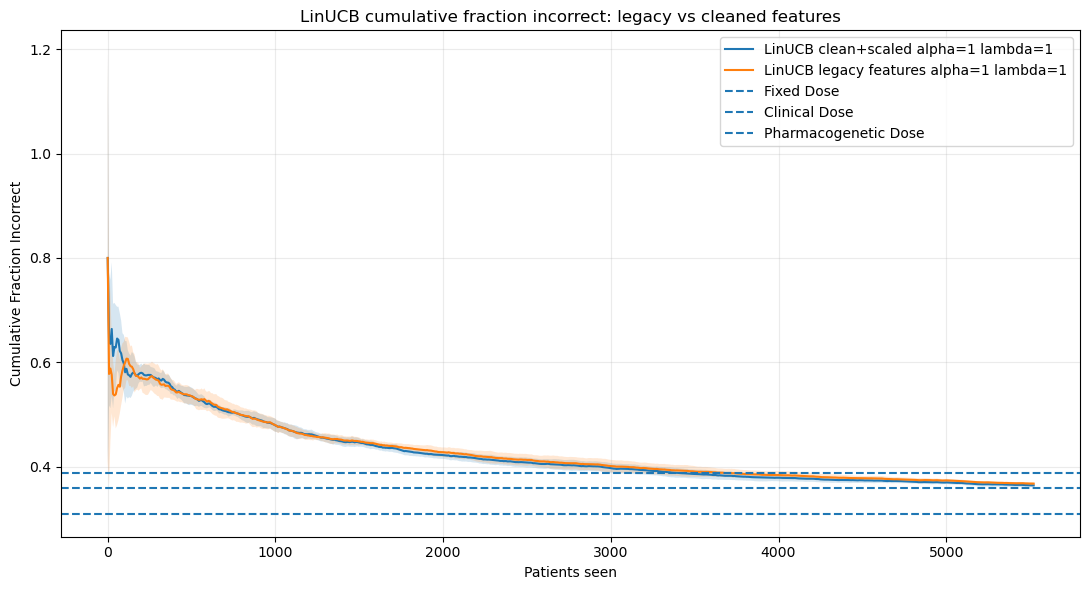

In [7]:
fig, ax = plot_learning_curves(
    linucb_demo_results,
    metric='cumulative_fraction_incorrect',
    baseline_rates=baseline_rates,
    title='LinUCB cumulative fraction incorrect: legacy vs cleaned features',
)
plt.show()

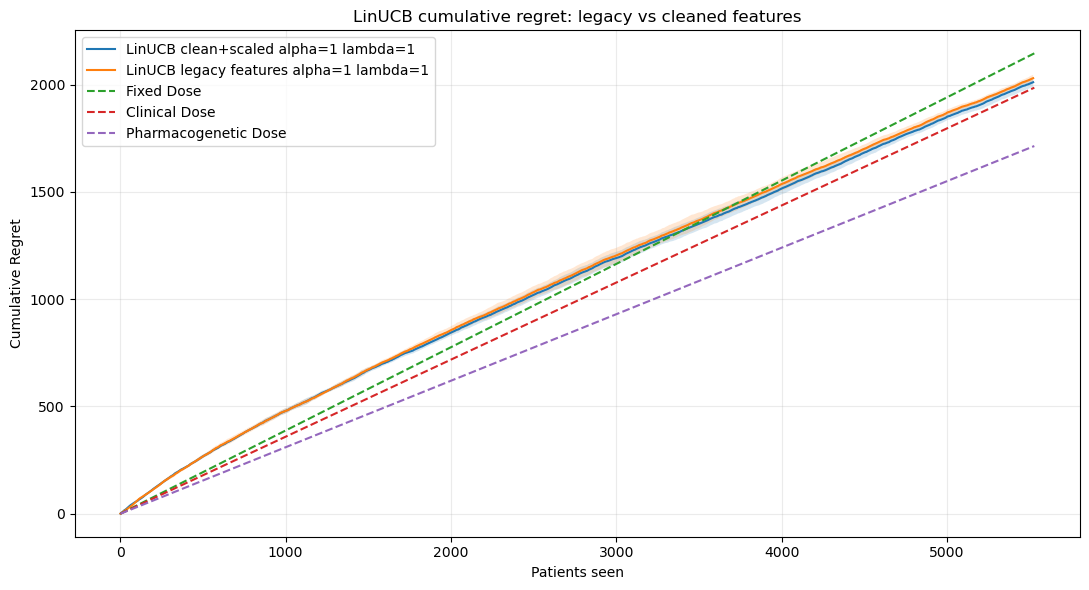

In [8]:
fig, ax = plot_learning_curves(
    linucb_demo_results,
    metric='cumulative_regret',
    baseline_rates=baseline_rates,
    title='LinUCB cumulative regret: legacy vs cleaned features',
)
plt.show()

## Tuned LinUCB / RidgeLinUCB grid

`lambda_reg=1.0` reproduces the original LinUCB initialization `A = I`. Larger or smaller values change the ridge prior strength. This section is intentionally small for a first pass; for final experiments, expand the seed count and grid.

In [9]:
ALPHAS = [0.1, 0.25, 0.5, 1.0, 2.0]
LAMBDA_REGS = [0.1, 1.0, 5.0, 10.0]
TUNING_SEEDS = range(3)

linucb_tuning_summary = tune_linucb_grid(
    linucb_cls=RidgeLinUCB,
    X=X_clean,
    y=y_clean,
    alphas=ALPHAS,
    lambda_regs=LAMBDA_REGS,
    seeds=TUNING_SEEDS,
    progress=True,
)

linucb_tuning_summary.head(10)

,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,alpha,lambda_reg
3,"LinUCB alpha=0.1, lambda=10.0",3,0.671611,0.002361,1815.333333,13.051181,0.328389,0.002361,0.694000,0.028844,0.002672,14.768802,0.002672,0.032641,0.10,10.0
7,"LinUCB alpha=0.25, lambda=10.0",3,0.669863,0.001266,1825.000000,7.000000,0.330137,0.001266,0.691333,0.029006,0.001433,7.921246,0.001433,0.032823,0.25,10.0
2,"LinUCB alpha=0.1, lambda=5.0",3,0.667692,0.004145,1837.000000,22.912878,0.332308,0.004145,0.691333,0.025166,0.004690,25.928363,0.004690,0.028478,0.10,5.0
11,"LinUCB alpha=0.5, lambda=10.0",3,0.666667,0.001090,1842.666667,6.027714,0.333333,0.001090,0.692000,0.028000,0.001234,6.821000,0.001234,0.031685,0.50,10.0
6,"LinUCB alpha=0.25, lambda=5.0",3,0.662506,0.003161,1865.666667,17.473790,0.337494,0.003161,0.684667,0.018037,0.003577,19.773455,0.003577,0.020411,0.25,5.0
15,"LinUCB alpha=1.0, lambda=10.0",3,0.659069,0.001105,1884.666667,6.110101,0.340931,0.001105,0.688000,0.020298,0.001251,6.914230,0.001251,0.022969,1.00,10.0
1,"LinUCB alpha=0.1, lambda=1.0",3,0.658225,0.008221,1889.333333,45.445939,0.341775,0.008221,0.687333,0.019630,0.009303,51.426921,0.009303,0.022213,0.10,1.0
10,"LinUCB alpha=0.5, lambda=5.0",3,0.656597,0.001309,1898.333333,7.234178,0.343403,0.001309,0.679333,0.025166,0.001481,8.186243,0.001481,0.028478,0.50,5.0
14,"LinUCB alpha=1.0, lambda=5.0",3,0.652496,0.004679,1921.000000,25.865034,0.347504,0.004679,0.692667,0.032517,0.005295,29.269042,0.005295,0.036796,1.00,5.0
5,"LinUCB alpha=0.25, lambda=1.0",3,0.648698,0.004533,1942.000000,25.059928,0.351302,0.004533,0.682667,0.013317,0.005130,28.357978,0.005130,0.015069,0.25,1.0


In [10]:
best_row = linucb_tuning_summary.iloc[0]
best_alpha = float(best_row['alpha'])
best_lambda = float(best_row['lambda_reg'])

print('Best alpha:', best_alpha)
print('Best lambda_reg:', best_lambda)

best_ridge_results = evaluate_bandit(
    name=f'Best RidgeLinUCB alpha={best_alpha}, lambda={best_lambda}',
    bandit_factory=lambda: RidgeLinUCB(
        alpha=best_alpha,
        n_arms=n_arms_clean,
        n_features=n_features_clean,
        lambda_reg=best_lambda,
    ),
    X=X_clean,
    y=y_clean,
    seeds=DEMO_SEEDS,
    progress=True,
)

comparison_results = pd.concat(
    [clean_linucb_results, best_ridge_results],
    ignore_index=True,
)

summarize_results(comparison_results, late_window=500)

Best alpha: 0.1
Best lambda_reg: 10.0


,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95
0,"Best RidgeLinUCB alpha=0.1, lambda=10.0",5,0.666715,0.007903,1842.4,43.689816,0.333285,0.007903,0.6904,0.021559,0.006928,38.295812,0.006928,0.018897
1,LinUCB clean+scaled alpha=1 lambda=1,5,0.635637,0.004385,2014.2,24.242525,0.364363,0.004385,0.6888,0.022786,0.003844,21.249510,0.003844,0.019973


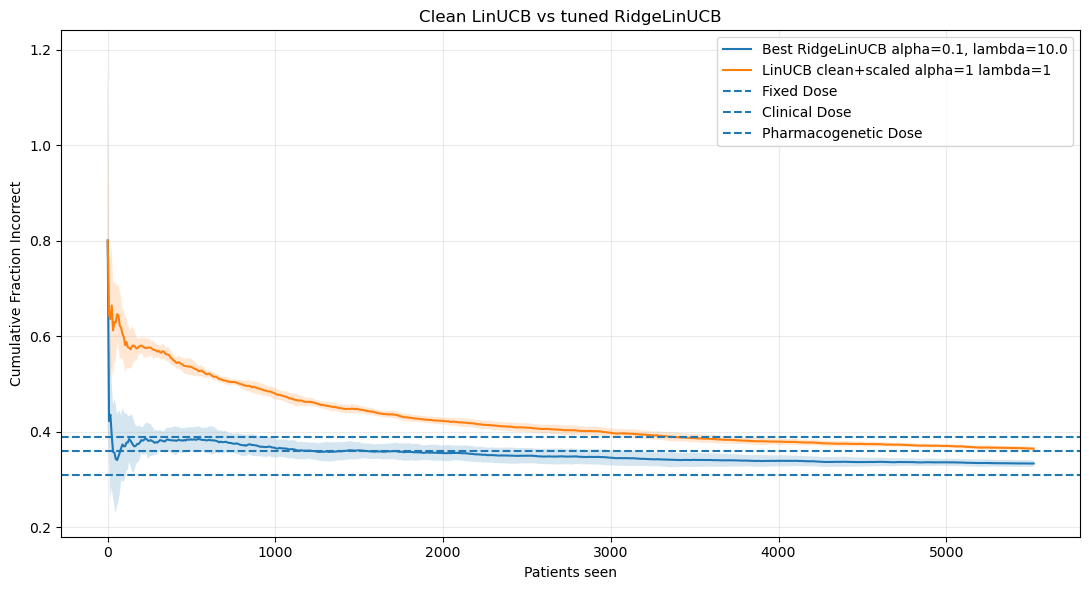

In [11]:
fig, ax = plot_learning_curves(
    comparison_results,
    metric='cumulative_fraction_incorrect',
    baseline_rates=baseline_rates,
    title='Clean LinUCB vs tuned RidgeLinUCB',
)
plt.show()